# A small estimation-to-design example

This notebook uses the Rooney--Biegler biochemical oxygen demand (BOD) model as a compact introduction to `parmest` and Pyomo.DoE.

By the end, you will be able to:

* label a Pyomo model as an `Experiment`;
* estimate parameters and a local covariance matrix;
* convert covariance into prior Fisher information;
* choose the next measurement time with Pyomo.DoE; and
* **close the loop** -- take the designed measurement, re-estimate, and check that the uncertainty actually shrank.

The last step is the one that makes the design step worth doing. A design is a prediction about how much a future measurement will help; until that measurement is taken and the parameters re-estimated, the prediction is untested.

The larger reaction-kinetics tutorials use the same workflow with dynamic models and more parameters.

```{warning}
**AI-drafted prose, not yet reviewed by Prof. Dowling.**

Some of the writing on this page was drafted or edited by an AI assistant and has not yet been reviewed: 8 added markdown cells, measured against the last version of this notebook predating AI editing (2026-08-17).

This notice is about the *prose only*. It says nothing either way about the code, the numbers or the figures, which are checked separately. It is removed once the page has been reviewed.
```

In [1]:
import sys

if "google.colab" in sys.modules:
    !wget -q "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    import helper
    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper

helper.set_plotting_style()

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyomo.environ as pyo
from pyomo.contrib.doe import DesignOfExperiments, ObjectiveLib
from pyomo.contrib.parmest.experiment import Experiment
from pyomo.contrib.parmest.parmest import Estimator

## Model and observations

The response model is

$$
y(t;\theta)=\theta_1\left(1-\exp(-\theta_2t)\right),
$$

where:

* $\theta_1$ is the long-time asymptote;
* $\theta_2$ is the approach rate; and
* $t$ is the measurement time.

We assume independent measurement noise with known standard deviation $\sigma=1$. In Pyomo's experiment suffix, `measurement_error` means **standard deviation**, not variance or weight.

In [3]:
data = pd.DataFrame(
    {
        "hour": [1, 2, 3, 4, 5, 7],
        "y": [8.3, 10.3, 19.0, 16.0, 15.6, 19.8],
    }
)
data

,hour,y
0,1,8.3
1,2,10.3
2,3,19.0
3,4,16.0
4,5,15.6
5,7,19.8


## A digital experiment

At the end of this notebook we will design a new measurement and then *take* it. The Rooney--Biegler data set is historical, so there is no seventh flask to go back to. We therefore build a **digital experiment**: a known ground truth $\theta^{\text{true}}$ plus Gaussian noise, which can be queried at any time we like.

The ground truth is chosen close to the fit we are about to obtain from the real data, so a simulated observation and a real one tell the same story.

Two data sets are now in play, and it is worth being blunt about which is which:

* `data` -- the **real** Rooney--Biegler observations. This stays the working data set for every estimate below, so the published numbers do not move.
* `simulated` -- six draws from the digital experiment at the same times. It appears once, to show the generator is calibrated against reality, and is never used for estimation.

The digital experiment earns its keep in the final section, where it supplies the one new measurement the design step asks for.

In [4]:
# Ground truth for the digital experiment. Deliberately close to the historical
# fit, so a simulated observation is indistinguishable from a real one by eye.
THETA_TRUE = {"asymptote": 19.0, "rate_constant": 0.53}
MEASUREMENT_STD = 1.0


def bod_response(t, theta):
    """Noise-free response y(t) = theta_1 * (1 - exp(-theta_2 * t))."""
    t = np.asarray(t, dtype=float)
    return theta["asymptote"] * (1.0 - np.exp(-theta["rate_constant"] * t))


def run_digital_experiment(t, rng):
    """Take one measurement at time t: the true response plus one noise draw."""
    return float(bod_response(t, THETA_TRUE) + rng.normal(0.0, MEASUREMENT_STD))


# A fixed seed makes every number in this notebook reproducible, including the
# new measurement taken after the design step.
calibration_rng = np.random.default_rng(60499)

simulated = pd.DataFrame(
    {
        "hour": data["hour"],
        "y": [run_digital_experiment(t, calibration_rng) for t in data["hour"]],
    }
)

# Side by side: the historical measurements and six draws from the simulator.
# They should look like samples from the same process, not like two data sets.
data.rename(columns={"y": "y (real)"}).assign(**{"y (digital)": simulated["y"].round(2)})

,hour,y (real),y (digital)
0,1,8.3,7.27
1,2,10.3,14.34
2,3,19.0,15.61
3,4,16.0,15.81
4,5,15.6,19.36
5,7,19.8,18.14


## Label one experiment

Pyomo's `Experiment` abstraction uses four local suffixes:

| Suffix | Role in this example |
|---|---|
| `experiment_outputs` | measured response and observed value |
| `unknown_parameters` | parameters and nominal values |
| `measurement_error` | response standard deviation |
| `experiment_inputs` | candidate measurement time |

`parmest` uses the first three. Pyomo.DoE also needs `experiment_inputs`.

In [5]:
class BODExperiment(Experiment):
    def __init__(
        self, data, measurement_standard_deviation=1.0, theta=None, design_bounds=(0, 10)
    ):
        self.data = dict(data)
        self.measurement_standard_deviation = measurement_standard_deviation
        self.design_bounds = design_bounds
        self.theta = theta or {"asymptote": 15.0, "rate_constant": 0.5}
        self.model = None

    def create_model(self):
        m = self.model = pyo.ConcreteModel()
        m.asymptote = pyo.Var(initialize=self.theta["asymptote"])
        m.rate_constant = pyo.Var(initialize=self.theta["rate_constant"])
        m.asymptote.fix()
        m.rate_constant.fix()

        m.hour = pyo.Var(initialize=self.data["hour"], bounds=self.design_bounds)
        m.hour.fix()
        m.y = pyo.Var(initialize=max(self.data["y"], 1e-3), domain=pyo.PositiveReals)
        m.response = pyo.Constraint(
            expr=m.y == m.asymptote * (1 - pyo.exp(-m.rate_constant * m.hour))
        )

    def label_model(self):
        m = self.model
        m.experiment_outputs = pyo.Suffix(direction=pyo.Suffix.LOCAL)
        m.experiment_outputs.update([(m.y, self.data["y"])])

        m.unknown_parameters = pyo.Suffix(direction=pyo.Suffix.LOCAL)
        m.unknown_parameters.update(
            (parameter, pyo.value(parameter))
            for parameter in [m.asymptote, m.rate_constant]
        )

        m.measurement_error = pyo.Suffix(direction=pyo.Suffix.LOCAL)
        m.measurement_error.update(
            [(m.y, self.measurement_standard_deviation)]
        )

        m.experiment_inputs = pyo.Suffix(direction=pyo.Suffix.LOCAL)
        m.experiment_inputs.update([(m.hour, self.data["hour"])])

    def get_labeled_model(self):
        if self.model is None:
            self.create_model()
            self.label_model()
        return self.model

## Estimate the parameters

Create one experiment per row. The weighted sum of squared errors divides each residual by its measurement standard deviation before squaring.

Covariance estimation needs more experiments than unknown parameters. Two observations could interpolate two parameters, but they cannot support the covariance needed for the next step.

In [6]:
def estimate_parameters(observations):
    """Fit the BOD model to a table of (hour, y) rows.

    One `BODExperiment` is created per row. Returns the weighted sum of squared
    errors, the fitted parameters, and the local covariance matrix -- everything
    needed both to report a fit and to seed the next experimental design.
    """
    experiments = [BODExperiment(row) for row in observations.to_dict("records")]
    estimator = Estimator(experiments, obj_function="SSE_weighted")

    weighted_sse, theta = estimator.theta_est()
    covariance = np.asarray(estimator.cov_est(method="reduced_hessian"))
    return weighted_sse, theta, covariance


weighted_sse, theta, covariance = estimate_parameters(data)

standard_deviation = np.sqrt(np.diag(covariance))
correlation = covariance / np.outer(standard_deviation, standard_deviation)

print(f"Weighted SSE: {weighted_sse:.6f}")
print("Parameters:", theta)
print("Covariance:\n", covariance)
print("Correlation:\n", correlation)

assert np.isclose(theta["asymptote"], 19.1426, rtol=2e-4)
assert np.isclose(theta["rate_constant"], 0.53109, rtol=2e-4)

Weighted SSE: 2.165856
Parameters: {'asymptote': 19.142575284772914, 'rate_constant': 0.531091377067967}
Covariance:
 [[ 0.94741493 -0.0654448 ]
 [-0.0654448   0.00624408]]
Correlation:
 [[ 1.        -0.8508847]
 [-0.8508847  1.       ]]


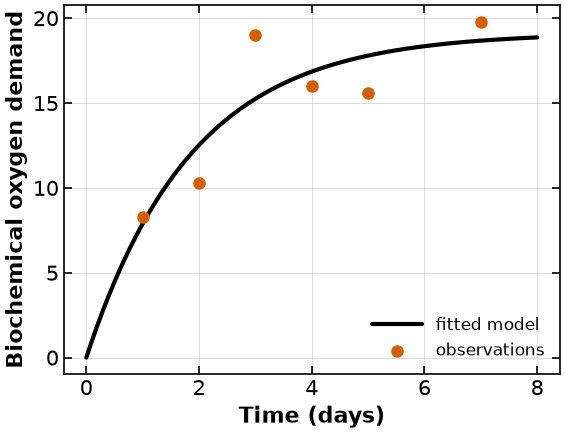

In [7]:
t_plot = np.linspace(0, 8, 250)
y_fit = theta["asymptote"] * (1 - np.exp(-theta["rate_constant"] * t_plot))

plt.plot(t_plot, y_fit, color="black", label="fitted model")
plt.scatter(data["hour"], data["y"], color="#D55E00", label="observations", zorder=3)
plt.xlabel("Time (days)")
plt.ylabel("Biochemical oxygen demand")
plt.grid(True)
plt.legend()
plt.show()

## From covariance to experimental design

The covariance becomes prior information:

$$\mathbf{F}_{\mathrm{prior}}=\mathbf{V}_{\theta}^{-1}.$$

For one new measurement with standard deviation 1,

$$
\mathbf{F}_{\mathrm{new}}(t)=\mathbf{F}_{\mathrm{prior}}+
\mathbf{q}(t)\mathbf{q}(t)^\mathsf{T},
$$

with sensitivity vector

$$
\mathbf{q}(t)=
\begin{bmatrix}
1-\exp(-\theta_2t)\\
\theta_1t\exp(-\theta_2t)
\end{bmatrix}.
$$

The two sensitivity components favor different time regions. A useful design balances the new direction against information already contained in the prior.

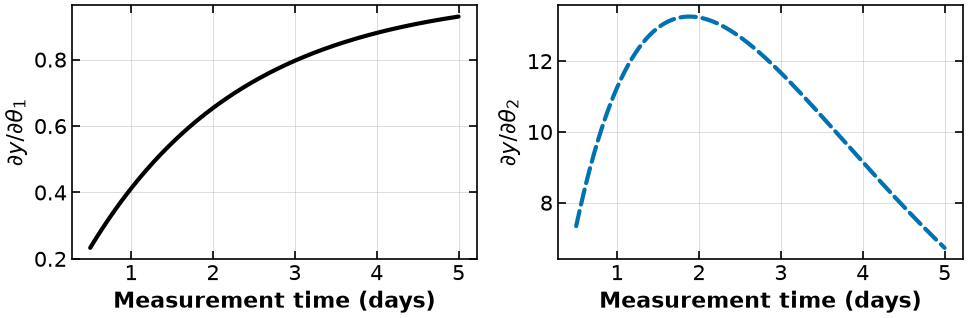

In [8]:
t_design = np.linspace(0.5, 5, 300)
q_asymptote = 1 - np.exp(-theta["rate_constant"] * t_design)
q_rate = theta["asymptote"] * t_design * np.exp(-theta["rate_constant"] * t_design)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(t_design, q_asymptote, color="black")
axes[0].set_ylabel(r"$\partial y/\partial\theta_1$")
axes[1].plot(t_design, q_rate, color="#0072B2", linestyle="--")
axes[1].set_ylabel(r"$\partial y/\partial\theta_2$")
for ax in axes:
    ax.set_xlabel("Measurement time (days)")
    ax.grid(True)
plt.tight_layout()
plt.show()

## Optimize the next measurement

Pyomo 6.10 configures the objective and solver behavior in the `DesignOfExperiments` constructor. `run_doe()` performs the optimization and stores the summary in `doe.results`.

The bounds in `BODExperiment` restrict the new measurement to 0.5--5 days.

In [9]:
prior_fim = np.linalg.inv(covariance)
design_experiment = BODExperiment(
    {"hour": 2.0, "y": 10.0},
    measurement_standard_deviation=1.0,
    theta=dict(theta),
    design_bounds=(0.5, 5.0),
)

# Pyomo.DoE defaults to the HSL linear solver MA57, which is not part of the
# course environment. Pass an explicit Ipopt configured with MUMPS instead;
# without it the failure surfaces as "Model from experiment did not solve
# appropriately", which reads like a modeling error rather than a missing library.
ipopt = pyo.SolverFactory("ipopt")
ipopt.options["linear_solver"] = "mumps"

doe = DesignOfExperiments(
    experiment=design_experiment,
    fd_formula="central",
    step=1e-3,
    objective_option=ObjectiveLib.determinant,
    prior_FIM=prior_fim,
    improve_cholesky_roundoff_error=True,
    solver=ipopt,
    tee=False,
)
doe.run_doe(model=doe.create_doe_model())

optimal_time = doe.results["Experiment Design"][0]
print(f"D-optimal next measurement: {optimal_time:.6f} days")

D-optimal next measurement: 1.502729 days


## Verify with an independent calculation

For this two-parameter model, a dense grid is cheap. It provides an independent check on the software formulation and local optimizer.

Dense-grid optimum: 1.503500 days
Prior log determinant:   6.417511
Updated log determinant: 6.755141


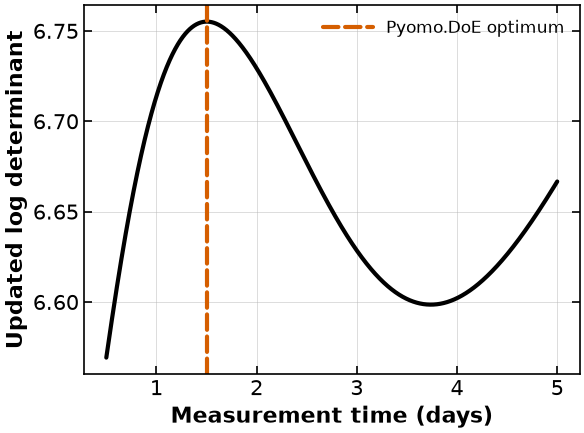

In [10]:
def updated_fim(t):
    sensitivity = np.array(
        [
            1 - np.exp(-theta["rate_constant"] * t),
            theta["asymptote"] * t * np.exp(-theta["rate_constant"] * t),
        ]
    )
    return prior_fim + np.outer(sensitivity, sensitivity)


grid = np.linspace(0.5, 5, 2001)
grid_logdet = np.array([np.linalg.slogdet(updated_fim(t))[1] for t in grid])
grid_time = grid[np.argmax(grid_logdet)]

print(f"Dense-grid optimum: {grid_time:.6f} days")
print(f"Prior log determinant:   {np.linalg.slogdet(prior_fim)[1]:.6f}")
print(f"Updated log determinant: {grid_logdet.max():.6f}")
assert abs(optimal_time - grid_time) < 0.02

plt.plot(grid, grid_logdet, color="black")
plt.axvline(optimal_time, color="#D55E00", linestyle="--", label="Pyomo.DoE optimum")
plt.xlabel("Measurement time (days)")
plt.ylabel("Updated log determinant")
plt.grid(True)
plt.legend()
plt.show()

## Close the loop: take the designed measurement

The design step produced a *time*, not data. Closing the loop means going back to the experiment, measuring at $t^\star$, appending the result, and re-estimating.

This is exactly where the digital experiment is needed: we evaluate the true response at $t^\star$, add one noise draw, and hand the seven-point data set back to `parmest`.

The quantity to watch is $\det\mathbf{V}_\theta$. Because the 95% confidence region is the ellipse

$$(\theta-\hat\theta)^{\mathsf{T}}\mathbf{V}_\theta^{-1}(\theta-\hat\theta)\le\chi^2_{2,0.95}=5.991,$$

its area is $\pi\,\chi^2_{2,0.95}\sqrt{\det\mathbf{V}_\theta}$. A smaller determinant is a smaller ellipse, and D-optimal design maximizes $\det\mathbf{F}$, which is the same objective seen from the other side.

In [11]:
# A separate random stream for the closed loop, so the new measurement does not
# depend on how many draws the calibration table above happened to consume.
loop_rng = np.random.default_rng(2026)

new_observation = run_digital_experiment(optimal_time, loop_rng)
print(f"Measured at t* = {optimal_time:.4f} days:  y = {new_observation:.4f}")
print(f"Noise-free truth at t*:        y = {bod_response(optimal_time, THETA_TRUE):.4f}")

augmented = pd.concat(
    [data, pd.DataFrame({"hour": [optimal_time], "y": [new_observation]})],
    ignore_index=True,
)
augmented

Measured at t* = 1.5027 days:  y = 9.6392
Noise-free truth at t*:        y = 10.4324


,hour,y
0,1.000000,8.300000
1,2.000000,10.300000
2,3.000000,19.000000
3,4.000000,16.000000
4,5.000000,15.600000
5,7.000000,19.800000
6,1.502729,9.639235


In [12]:
CHI2_95_2DOF = 5.991  # 95% quantile of the chi-squared distribution, 2 degrees of freedom


def ellipse_area(cov):
    """Area of the 95% confidence ellipse implied by a 2x2 covariance matrix."""
    return np.pi * CHI2_95_2DOF * np.sqrt(np.linalg.det(cov))


def summarize(label, theta, cov):
    """One row of the before/after comparison table."""
    sd = np.sqrt(np.diag(cov))
    return {
        "design": label,
        "theta_1": theta["asymptote"],
        "theta_2": theta["rate_constant"],
        "sd(theta_1)": sd[0],
        "sd(theta_2)": sd[1],
        "det(V)": np.linalg.det(cov),
        "ellipse area": ellipse_area(cov),
    }


sse_after, theta_after, covariance_after = estimate_parameters(augmented)

print("Covariance before (6 observations):\n", covariance)
print("\nCovariance after  (7 observations, measured at t*):\n", covariance_after)

closed_loop = pd.DataFrame(
    [
        summarize("before: 6 observations", theta, covariance),
        summarize(f"after: + measurement at t* = {optimal_time:.3f}", theta_after, covariance_after),
    ]
)
closed_loop

Covariance before (6 observations):
 [[ 0.94741493 -0.0654448 ]
 [-0.0654448   0.00624408]]

Covariance after  (7 observations, measured at t*):
 [[ 0.98249189 -0.05718414]
 [-0.05718414  0.0044708 ]]


,design,theta_1,theta_2,sd(theta_1),sd(theta_2),det(V),ellipse area
0,before: 6 observations,19.142575,0.531091,0.973352,0.079020,0.001633,0.760509
1,after: + measurement at t* = 1.503,19.365978,0.502872,0.991207,0.066864,0.001123,0.630584


In [13]:
determinant_drop = 1 - np.linalg.det(covariance_after) / np.linalg.det(covariance)
area_drop = 1 - ellipse_area(covariance_after) / ellipse_area(covariance)

print(f"det(V) fell by {100 * determinant_drop:.1f}%")
print(f"95% ellipse area fell by {100 * area_drop:.1f}%")

# Sanity check: one well-placed measurement should measurably shrink the region.
assert np.linalg.det(covariance_after) < np.linalg.det(covariance)

det(V) fell by 31.2%
95% ellipse area fell by 17.1%


## A control: was the design step worth it?

A shrinking ellipse is not by itself evidence that the *design* helped. Any seventh observation adds information. The question is whether $t^\star$ adds more than a time we could have picked without optimizing.

Two controls, both inside the same 0.5--5 day window:

* $t=0.5$ days, the time the dense grid identified as the **worst** in the window; and
* $t=5$ days, the naive "measure at the end" choice.

Each control uses its own noise draw, so the three augmented data sets differ in the new point only.

In [14]:
grid_worst_time = grid[np.argmin(grid_logdet)]
print(f"Worst time on the dense grid: {grid_worst_time:.4f} days")

candidates = {
    f"optimal t* = {optimal_time:.3f}": optimal_time,
    f"worst on grid, t = {grid_worst_time:.3f}": grid_worst_time,
    "end of window, t = 5.0": 5.0,
}

# The prediction the design step makes, before any data are collected. It depends
# only on the sensitivity vector and the prior, not on the value that comes back.
predicted = []
for label, t_new in candidates.items():
    fim = updated_fim(t_new)
    predicted_cov = np.linalg.inv(fim)
    predicted.append(
        {
            "design": label,
            "predicted det(V)": np.linalg.det(predicted_cov),
            "predicted reduction": 1 - np.linalg.det(predicted_cov) / np.linalg.det(covariance),
        }
    )

pd.DataFrame(predicted)

Worst time on the dense grid: 0.5000 days


,design,predicted det(V),predicted reduction
0,optimal t* = 1.503,0.001165,0.286541
1,"worst on grid, t = 0.500",0.001403,0.140764
2,"end of window, t = 5.0",0.001273,0.220543


In [15]:
# Now take each measurement and re-estimate. The optimal row reuses the
# measurement already taken above, so this table and the one before it agree;
# each control draws its own noise from the same stream.
realized_covariance = {}
before = summarize("before: 6 observations", theta, covariance)
before["reduction in det(V)"] = 0.0
realized = [before]

for label, t_new in candidates.items():
    if t_new == optimal_time:
        y_new = new_observation
    else:
        y_new = run_digital_experiment(t_new, loop_rng)

    trial = pd.concat(
        [data, pd.DataFrame({"hour": [t_new], "y": [y_new]})], ignore_index=True
    )
    _, theta_trial, covariance_trial = estimate_parameters(trial)
    realized_covariance[label] = covariance_trial

    row = summarize(label, theta_trial, covariance_trial)
    row["reduction in det(V)"] = 1 - row["det(V)"] / np.linalg.det(covariance)
    realized.append(row)

pd.DataFrame(realized)

,design,theta_1,theta_2,sd(theta_1),sd(theta_2),det(V),ellipse area,reduction in det(V)
0,before: 6 observations,19.142575,0.531091,0.973352,0.079020,0.001633,0.760509,0.000000
1,optimal t* = 1.503,19.365978,0.502872,0.991207,0.066864,0.001123,0.630584,0.312493
2,"worst on grid, t = 0.500",19.096537,0.536537,0.930892,0.074108,0.001407,0.706077,0.138023
3,"end of window, t = 5.0",18.441329,0.564221,0.827705,0.082536,0.001407,0.705982,0.138257


## One realization is not evidence

The table above compares three single draws. That is a weak comparison: $\mathbf{V}_\theta$ from `parmest` depends on the realized residuals as well as on where the measurement was placed, so an unlucky draw at $t^\star$ can beat a lucky draw at the worst time.

The Fisher information prediction has no such noise in it. To check that the prediction is the right summary of what actually happens, repeat each placement over many noise draws and average the realized $\det\mathbf{V}_\theta$.

All three placements share the same standardized draws -- common random numbers -- so the comparison is between *times*, not between lucky and unlucky noise.

In [16]:
REPLICATES = 50
standardized_draws = np.random.default_rng(7).normal(0.0, 1.0, REPLICATES)

study = []
for label, t_new in candidates.items():
    determinants = []
    for z in standardized_draws:
        y_new = float(bod_response(t_new, THETA_TRUE) + MEASUREMENT_STD * z)
        trial = pd.concat(
            [data, pd.DataFrame({"hour": [t_new], "y": [y_new]})], ignore_index=True
        )
        determinants.append(np.linalg.det(estimate_parameters(trial)[2]))

    determinants = np.array(determinants)
    study.append(
        {
            "design": label,
            "mean det(V)": determinants.mean(),
            "mean reduction": 1 - determinants.mean() / np.linalg.det(covariance),
            "predicted reduction": 1
            - np.linalg.det(np.linalg.inv(updated_fim(t_new))) / np.linalg.det(covariance),
        }
    )

pd.DataFrame(study)

,design,mean det(V),mean reduction,predicted reduction
0,optimal t* = 1.503,0.001150,0.295569,0.286541
1,"worst on grid, t = 0.500",0.001399,0.143245,0.140764
2,"end of window, t = 5.0",0.001301,0.202950,0.220543


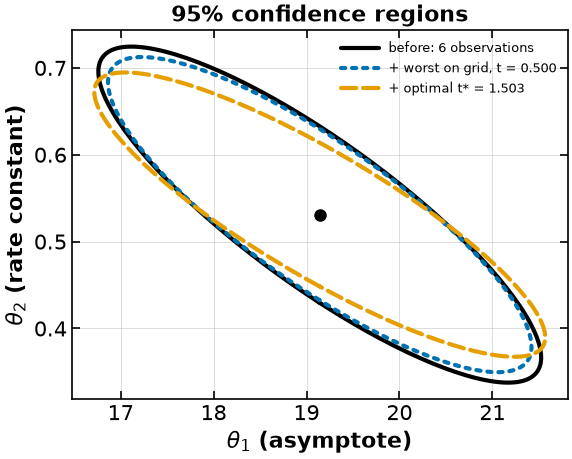

In [17]:
def confidence_ellipse(center, cov, n_points=200):
    """Points on the 95% confidence ellipse of a 2x2 covariance matrix."""
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    angle = np.linspace(0, 2 * np.pi, n_points)
    unit_circle = np.vstack([np.cos(angle), np.sin(angle)])
    radii = np.sqrt(CHI2_95_2DOF * eigenvalues)
    return (eigenvectors @ (radii[:, None] * unit_circle)).T + np.array(center)


# All three ellipses are drawn around the six-observation estimate. Each fit has
# its own center, but overlaying them there would mix a change in shape with a
# change in location; only the shape is what the design step controls.
center = [theta["asymptote"], theta["rate_constant"]]

optimal_label, worst_label = list(candidates)[0], list(candidates)[1]
ellipses = [
    (covariance, "-", "before: 6 observations"),
    (realized_covariance[worst_label], ":", f"+ {worst_label}"),
    (realized_covariance[optimal_label], "--", f"+ {optimal_label}"),
]

for cov, style, label in ellipses:
    points = confidence_ellipse(center, cov)
    plt.plot(points[:, 0], points[:, 1], linestyle=style, label=label)

plt.scatter(*center, color="black", zorder=3)
plt.xlabel(r"$\theta_1$ (asymptote)")
plt.ylabel(r"$\theta_2$ (rate constant)")
plt.title("95% confidence regions")
plt.grid(True)
plt.legend(fontsize=9)
plt.show()

Read the figure by shape, not only by size. The worst placement (dotted) is almost indistinguishable from the prior: it measures where the response is barely sensitive to either parameter, so it adds little. The D-optimal region (dashed) is shorter along the long axis -- the strongly correlated direction that dominates the uncertainty -- and very slightly wider across it. That trade is what a determinant criterion buys: it attacks the direction that is worst known, rather than shrinking every direction a little.

## Key takeaways

* Parameter estimation turns measurements into fitted parameters and an uncertainty description.
* The inverse covariance is prior Fisher information for the next design.
* Experimental design asks where a new measurement adds information not already supplied by the prior.
* **A design is only a prediction.** Closing the loop -- taking the measurement and re-estimating -- is what tests it, and a digital experiment makes that possible when the real apparatus is gone.
* **Check the design against a control.** That a seventh observation shrinks the confidence region proves nothing on its own; the comparison that matters is against a measurement placed without optimizing.
* A single realization is a weak comparison, because the estimated covariance also responds to the residuals that happen to come back. Average over draws, or compare the noise-free Fisher information prediction.
* FIM designs are local: different nominal parameters, noise models, bounds, or priors can change the answer.
* Small examples permit independent checks. Use them before trusting a larger dynamic design.